# Linear Regression from Scratch — A Hands-On Tutorial

*Build, train, and evaluate a linear-regression model using only NumPy — then see it learn, step by step.*

---

## Overview

This tutorial turns a compact `linear_regression.py` script into a complete, visual learning experience.

- **What it teaches:** how linear regression works, how gradient descent trains it, and how to evaluate a regression model.
- **Who it's for:** beginners and intermediate learners who know a little Python and want to understand the math *and* the code behind the simplest ML model.
- **ML task type:** **Regression** — predicting a *continuous number* (not a category).

### Learning outcomes
By the end you will be able to:
1. Explain the line equation $\hat{y} = wx + b$ and what $w$ and $b$ mean.
2. Describe how **gradient descent** adjusts the parameters to reduce error.
3. Evaluate a regression model with **MSE** and **R²**.
4. Read an **actual-vs-predicted** plot and a **residual** plot to judge model quality.

### What you will build
A from-scratch `LinearRegression` class (no scikit-learn model) that fits a straight line to data, plus a set of charts — including an **animation of the line being learned** iteration by iteration.

## 1. The concept in plain language

**Linear regression** fits the *best straight line* through your data so you can predict a **continuous number**.

The model is just the equation of a line:

$$\hat{y} = w \cdot x + b$$

- $x$ — the input **feature** (e.g. size of a house)
- $\hat{y}$ — the **prediction** (e.g. its price)
- $w$ — the **weight** (slope): how much $y$ changes when $x$ increases by 1
- $b$ — the **bias** (intercept): the value of $y$ when $x = 0$

### Everyday examples
Linear regression shows up anywhere one number tends to move *in step* with another:

| Domain | Input feature (x) | Predicted value (ŷ) |
|--------|-------------------|----------------------|
| Real estate | house size (m²) | selling price |
| Retail | advertising budget | monthly sales |
| Education | hours studied | exam score |
| Health | body-mass index (BMI) | blood pressure / risk score |
| Energy | outside temperature | electricity demand |
| Transport | trip distance (km) | taxi fare |
| Agriculture | rainfall (mm) | crop yield |

In every row, more of the input tends to mean more (or less) of the output — and a straight line captures that trend.

### Two simple analogies
1. **Balancing a ruler.** Picture a cloud of pins on a board. You tilt and slide a ruler until it sits as close to *all* the pins as possible. The final tilt is the **slope (w)**; where it crosses the axis is the **intercept (b)**.
2. **A line of best guess.** If someone tells you a house is 120 m², you slide up to that spot on the line and read off the predicted price. The line is your rule-of-thumb for turning any input into a prediction.

"As close as possible" has a precise meaning: the line that makes the **total squared vertical gap** between the points and the line as small as possible. Linear regression finds that line automatically.

### How it learns: gradient descent
The model starts with a flat line ($w=0, b=0$) and repeatedly nudges $w$ and $b$ in the direction that reduces the error — like walking downhill on an error surface until it reaches the bottom. Each nudge is controlled by the **learning rate**.

### Key terms
- **Feature / target** — the input ($x$) and the thing we predict ($y$).
- **Loss (MSE)** — average squared error; what we minimize.
- **Learning rate** — step size for each update; too big overshoots, too small is slow.
- **Epoch / iteration** — one full update of the parameters.

### See it — which straight line is "best"?

Before any real code, here is the whole idea in one picture. The animation below sweeps a straight line through a fixed set of points at different slopes. The **red bars** are the errors (the vertical distance from each point to the line), and the title shows the **total squared error**.

**Learning objective:** watch the total error *shrink to a minimum and then grow again*. The slope where it is smallest is exactly the line linear regression is looking for — this is "best fit = smallest total squared error" made visible. (Press ▶ to play.)

In [ ]:
# Self-contained intuition demo (imports here so it runs even before Section 0)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# A small, fixed set of points to fit a line through
rng = np.random.default_rng(0)
demo_x = np.linspace(0, 10, 15)
demo_y = 2.5 * demo_x + 4 + rng.normal(0, 3, size=demo_x.size)
mean_x, mean_y = demo_x.mean(), demo_y.mean()

# Sweep the slope; keep the line through the data's centre so only tilt changes
slopes = np.linspace(0.0, 5.0, 40)
edge_x = np.array([demo_x.min() - 1, demo_x.max() + 1])

fig, ax = plt.subplots(figsize=(7, 5))

def draw_candidate(i):
    ax.clear()
    slope = slopes[i]
    intercept = mean_y - slope * mean_x          # pin line through (mean_x, mean_y)
    y_on_line = slope * demo_x + intercept

    # red bars = the error (vertical distance from each point to the line)
    for xi, yi, yhat in zip(demo_x, demo_y, y_on_line):
        ax.plot([xi, xi], [yi, yhat], color="red", linewidth=1.2, alpha=0.7)

    ax.plot(edge_x, slope * edge_x + intercept, color="black", linewidth=2, label="candidate line")
    ax.scatter(demo_x, demo_y, color="steelblue", zorder=5, label="data points")

    total_sq_error = np.sum((demo_y - y_on_line) ** 2)
    ax.set_title(f"slope = {slope:.2f}    total squared error = {total_sq_error:,.0f}")
    ax.set_xlabel("x (feature)")
    ax.set_ylabel("y (target)")
    ax.set_ylim(demo_y.min() - 8, demo_y.max() + 8)
    ax.legend(loc="upper left")

concept_anim = animation.FuncAnimation(fig, draw_candidate, frames=len(slopes), interval=150)
plt.close(fig)  # avoid a duplicate static figure
HTML(concept_anim.to_jshtml())

**What to notice:** as the line tilts, the red error bars get shorter, reach their shortest at the best slope, then grow again. There is a single **"sweet spot" slope** that minimizes the total error — and that's the line the model will learn. (To keep the story simple we pin the line through the data's center and vary only the slope.)

## 2. The machine-learning workflow

Almost every supervised-learning project follows the same path. Here is how this notebook maps onto it:

```mermaid
flowchart LR
    A[Generate / load data] --> B[Explore the data]
    B --> C[Train / test split]
    C --> D[Train model - gradient descent]
    D --> E[Predict on test set]
    E --> F[Evaluate - MSE & R squared]
    F --> G[Visualise fit & residuals]
    G --> H[Interpret & improve]
```

| Step | What it means | Where in this notebook |
|------|---------------|------------------------|
| Data loading | Get numbers to learn from | Section 5 |
| Data exploration (EDA) | Look at shape, stats, distributions | Section 6 |
| Train/test split | Hold out data for honest evaluation | Section 5 |
| Model training | Fit the line with gradient descent | Section 7 |
| Prediction | Apply the line to unseen inputs | Section 7 |
| Evaluation | Measure error with MSE and R² | Section 8 |
| Interpretation | Read the fit, residuals, and animation | Sections 9–10 |

**Note on scaling:** this toy dataset has a single, already well-scaled feature, so we skip feature scaling. For real multi-feature data you would typically **standardize** features first, because gradient descent converges much faster when all features share a similar range.

## 0. Setup

We use a small, standard stack:

- **NumPy** — the array math behind the model (dot products, gradients).
- **pandas** — to hold the data as a table for quick exploration.
- **Matplotlib / seaborn** — for the charts.
- **scikit-learn** — *only* to generate a toy dataset and split it. **The linear-regression model itself is written from scratch.**

> If a package is missing, install it once with:
> `pip install numpy pandas matplotlib seaborn scikit-learn`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Nicer default styling for all plots
sns.set_theme(style="whitegrid")
%matplotlib inline

## 3. Evaluation metrics (defined first so we can reuse them)

Before the model, we define the two numbers we'll use to judge it:

- **Mean Squared Error (MSE)** — the average of the squared gaps between predictions and truth. **Lower is better**; 0 means perfect. Squaring punishes big misses more and keeps the sign from cancelling out.
- **R² (coefficient of determination)** — the fraction of the target's variance the model explains. **1.0 is perfect**, 0 means "no better than predicting the mean", and negative means "worse than the mean".

$$\text{MSE} = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2 \qquad R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

> **Refactor note:** the original script computed R² from a correlation coefficient (`np.corrcoef(...)**2`). Here it uses the **standard definition** $1 - SS_{res}/SS_{tot}$. They agree for a good fit, but the standard formula is more general (it can correctly go negative for a bad model), so it's the better teaching version.

In [3]:
def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination (R²).

    Computed with the standard definition ``R² = 1 - SS_res / SS_tot``:
    1.0 is a perfect fit, 0 means "no better than predicting the mean",
    and a negative value means the model is worse than the mean.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth target values.
    y_pred : array-like of shape (n_samples,)
        Predicted target values.

    Returns
    -------
    float
        The R² score.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)          # unexplained variation
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # total variation
    return float(1 - ss_res / ss_tot)


def mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean squared error (MSE): the average of the squared prediction errors.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth target values.
    y_pred : array-like of shape (n_samples,)
        Predicted target values.

    Returns
    -------
    float
        The mean squared error (lower is better).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))

**What just happened:** we defined `mean_squared_error` and `r2_score` as plain functions. They take the true values and the predictions and return a single number each. We'll call them after training to score the model. Notice both convert inputs with `np.array(...)` so they work with lists or NumPy arrays.

## 4. The model — Linear Regression from scratch

The class below is the whole model. It mirrors scikit-learn's estimator API:

- **`fit(X, y)`** — learns `weights` (w) and `bias` (b) by **gradient descent**.
- **`predict(X)`** — applies the learned line: `X · w + b`.

### How gradient descent works here
Each iteration does four things:
1. **Predict** with the current line: `y_pred = X·w + b`.
2. **Measure the error**: `y_pred − y`.
3. **Compute gradients** — the direction that increases error:
   $$dw = \tfrac{1}{n}X^{T}(\hat{y}-y), \qquad db = \tfrac{1}{n}\sum(\hat{y}-y)$$
4. **Step downhill**: subtract `learning_rate × gradient` from `w` and `b`.

Repeat `n_iterations` times and the line settles into the best fit.

**Parameters to notice:**
- `learning_rate` — step size. Too large → the line overshoots and diverges; too small → very slow learning.
- `n_iterations` — how many update steps to run.

### Coding best practices applied in this review
- **Type hints & NumPy-style docstrings** on every method, so the intent and shapes are explicit.
- **`np.asarray(..., dtype=float)`** and the `@` matrix-multiply operator for clean, modern NumPy.
- **`loss_history_`** records the MSE each iteration — enabling the *learning-curve* plot below and a convergence check (the trailing `_` is the scikit-learn convention for "set during fit").
- **`fit` returns `self`** so calls can be chained (e.g. `model.fit(X, y).predict(X)`).
- **Input validation**: `predict` raises a clear error if called before `fit`.

In [4]:
class LinearRegression:
    """Ordinary least-squares linear regression trained with batch gradient descent.

    The model learns a weight vector ``weights`` and a scalar ``bias`` so that
    predictions follow ``y_hat = X @ weights + bias``. Training minimises the mean
    squared error by repeatedly stepping the parameters against the gradient.

    Parameters
    ----------
    n_iterations : int, default 1000
        Number of full-batch gradient-descent updates to run.
    learning_rate : float, default 0.01
        Step size for each update. Too large diverges; too small learns slowly.

    Attributes
    ----------
    weights : np.ndarray of shape (n_features,)
        Learned coefficients, available after :meth:`fit`.
    bias : float
        Learned intercept, available after :meth:`fit`.
    loss_history_ : list[float]
        Mean squared error after each iteration — handy for plotting the
        learning curve and confirming that training converged.
    """

    def __init__(self, n_iterations: int = 1000, learning_rate: float = 0.01) -> None:
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0
        self.loss_history_: list[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        """Learn ``weights`` and ``bias`` from training data via gradient descent.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training features.
        y : array-like of shape (n_samples,)
            Training targets.

        Returns
        -------
        LinearRegression
            The fitted estimator (returned so calls can be chained).
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        # Start from a flat line: zero weights and zero bias.
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history_ = []

        for _ in range(self.n_iterations):
            # 1) Forward pass: predictions with the current parameters.
            y_pred = X @ self.weights + self.bias

            # 2) Gradients of the mean squared error w.r.t. weights and bias.
            error = y_pred - y
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            # 3) Gradient-descent step: move parameters downhill.
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # 4) Record the loss so we can visualise convergence later.
            self.loss_history_.append(float(np.mean(error ** 2)))

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict target values for ``X`` using the learned line.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Input features.

        Returns
        -------
        np.ndarray of shape (n_samples,)
            Predicted target values.

        Raises
        ------
        RuntimeError
            If called before :meth:`fit` (the model has no weights yet).
        """
        if self.weights is None:
            raise RuntimeError("Model is not fitted yet — call fit() before predict().")
        X = np.asarray(X, dtype=float)
        return X @ self.weights + self.bias

**What just happened:** we defined the `LinearRegression` class but haven't trained anything yet — a class definition only creates the *blueprint*. `weights` and `bias` are `None` until we call `fit`. Because everything is plain NumPy, you can read exactly how the model learns, with no hidden library magic.

## 5. The data + train/test split

We generate a simple 1-feature regression dataset with scikit-learn's `make_regression`. Using a synthetic dataset means **there is no file to download** and the true relationship is genuinely linear (plus noise), which is perfect for learning.

- `n_samples=100` — 100 points.
- `n_features=1` — a single input, so we can plot everything in 2D.
- `noise=20` — scatter added around the line, so the fit isn't trivial.
- `random_state=42` — makes the data reproducible.

We then hold out **20%** as a **test set**. The model learns only from the training set; the test set is used to check how well it generalizes to unseen data.

In [5]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)


**What just happened:** `make_regression` returned a feature matrix `X` (shape `100 × 1`) and target `y`. `train_test_split` shuffled and carved off 20% for testing. From now on, `X_train`/`y_train` are for learning and `X_test`/`y_test` are the untouched exam the model must pass.

## 6. Exploratory data analysis (EDA)

Before training, we *look* at the data: its shape, whether values are missing or duplicated, its summary statistics, and — most importantly for regression — the **shape of the relationship** between the feature and the target.

In [6]:
# Put the data in a DataFrame for easy inspection
df = pd.DataFrame({"feature": X.ravel(), "target": y})

print("Shape (rows, cols):", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

display(df.head())
display(df.describe())

Shape (rows, cols): (100, 2)
Missing values: 0
Duplicate rows: 0


,feature,target
0,0.931280,62.687202
1,0.087047,-23.763981
2,-1.057711,-25.686766
3,0.314247,7.936457
4,-0.479174,-15.475495


,feature,target
count,100.000000,100.000000
mean,-0.103847,-2.564392
std,0.908168,46.342550
min,-2.619745,-126.703865
25%,-0.600906,-33.801999
50%,-0.126956,0.354463
75%,0.405952,25.794133
max,1.852278,116.377367


The table confirms the basics: 100 rows, 2 columns, **no missing values and no duplicates**, so no data cleaning is needed here (a luxury of synthetic data — real datasets usually need work at this step). The `describe()` summary shows the range and spread of both the feature and the target.

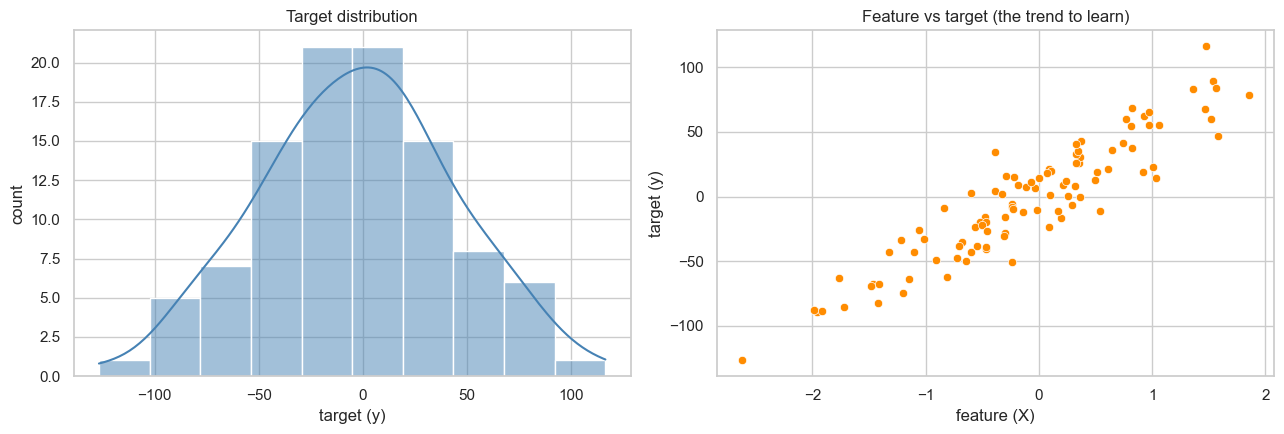

In [7]:
# Visualise the target distribution and the feature-vs-target relationship
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: how the target values are spread out
sns.histplot(df["target"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("target (y)")
axes[0].set_ylabel("count")

# Right: the relationship we want the model to learn
sns.scatterplot(data=df, x="feature", y="target", color="darkorange", ax=axes[1])
axes[1].set_title("Feature vs target (the trend to learn)")
axes[1].set_xlabel("feature (X)")
axes[1].set_ylabel("target (y)")

plt.tight_layout()
plt.show()

**Key insight:** the scatter on the right shows a clear upward trend — as the feature increases, the target increases roughly linearly. That straight-line pattern is exactly what linear regression is designed to capture, so we can expect a good fit. The target histogram (left) is roughly bell-shaped and centered near zero, which is typical for `make_regression` output.

*Why seaborn here?* For quick statistical views — a histogram with a smooth **KDE** curve and a clean scatter — seaborn produces publication-quality results in one line each, which is clearer for teaching than hand-built Matplotlib. We keep Matplotlib for the custom model-fit and animation plots later, where we need fine control.

## 7. Train the model

Now we create the model, call `fit` on the **training data** (this runs 1000 gradient-descent steps), and use `predict` on the **test data** to get predictions for points the model never saw.

In [8]:
reg_model = LinearRegression(n_iterations=1000, learning_rate=0.01)
reg_model.fit(X_train, y_train)
predictions = reg_model.predict(X_test)     


**What just happened:** `fit` ran gradient descent and stored the learned `weights` and `bias` inside `reg_model`. `predict` then turned the test inputs into predicted numbers stored in `predictions`. Nothing is printed yet — we score the result in the next section.

In [9]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")
    

Mean Squared Error: 220.02388898430726
R-squared Score: 0.8347999947644975


## 8. Evaluate the model

**How to read these two numbers:**
- **MSE** is in *squared target units*, so on its own it's hard to interpret — it's most useful for *comparing* models on the same data (lower = better).
- **R²** is the intuitive one: close to **1.0** means the line explains almost all the variation in the target. For this clean, linear dataset you should see a high R² (around 0.9+), confirming a strong fit.

### Visualising convergence — the learning curve

Our improved model now records the loss after **every** iteration in `loss_history_`. Plotting it shows *how* training progressed. A healthy learning curve **drops quickly, then flattens** as gradient descent settles into the best fit.

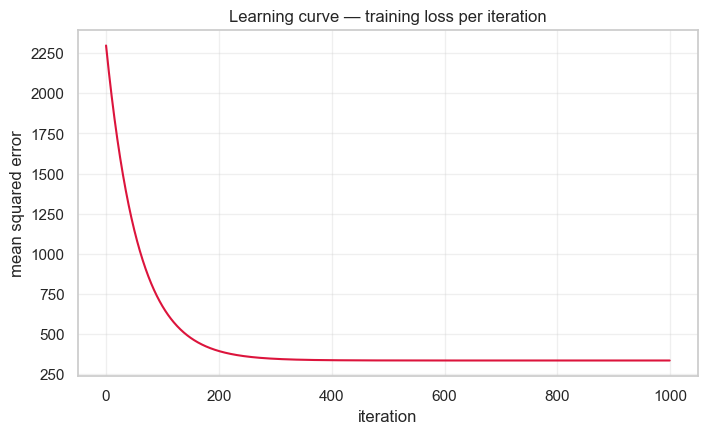

Loss at start: 2297.2
Loss at end:   335.7


In [10]:
# The model recorded the loss at every iteration in loss_history_
plt.figure(figsize=(8, 4.5))
plt.plot(reg_model.loss_history_, color="crimson")
plt.xlabel("iteration")
plt.ylabel("mean squared error")
plt.title("Learning curve — training loss per iteration")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Loss at start: {reg_model.loss_history_[0]:.1f}")
print(f"Loss at end:   {reg_model.loss_history_[-1]:.1f}")

**Key insight:** the steep early drop shows the biggest learning happens in the first few dozen iterations; the flat tail means extra iterations bring diminishing returns. If the curve were still falling steeply at the end, you'd raise `n_iterations`; if it *rose* or oscillated, you'd lower the `learning_rate`.

## 9. Visualising the fit

Numbers tell us *how well*; charts tell us *how*. First we draw the learned line over the data. A good fit should pass through the middle of the point cloud, with points scattered evenly above and below it.

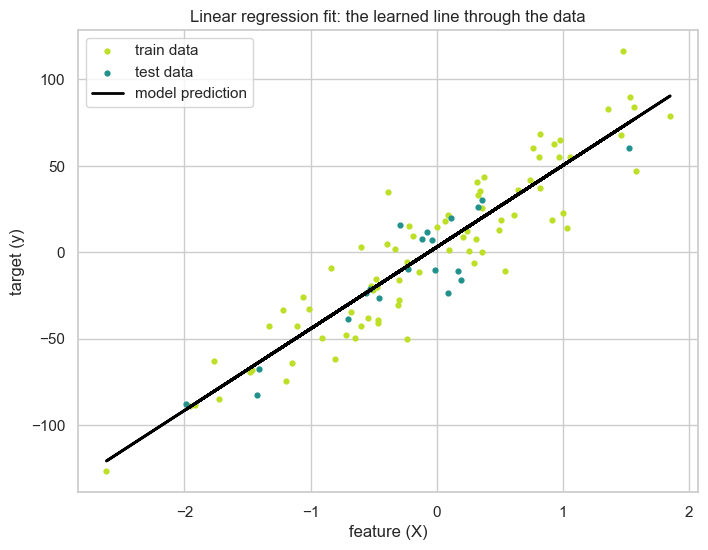

In [11]:
y_pred_line = reg_model.predict(X)   # the fitted straight line evaluated over all X

cmap = plt.get_cmap('viridis')
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color=cmap(0.9), s=12, label="train data")
plt.scatter(X_test, y_test, color=cmap(0.5), s=12, label="test data")
plt.plot(X, y_pred_line, color='black', linewidth=2, label="model prediction")
plt.xlabel("feature (X)")
plt.ylabel("target (y)")
plt.title("Linear regression fit: the learned line through the data")
plt.legend()
plt.show()

The black line is the model. Notice it runs through the center of both the training (dark) and test (lighter) points — a sign the model generalizes, not just memorizes.

### Actual vs predicted
Another way to judge a regressor: plot the **true** test values against the **predicted** ones. Perfect predictions would all fall on the diagonal line.

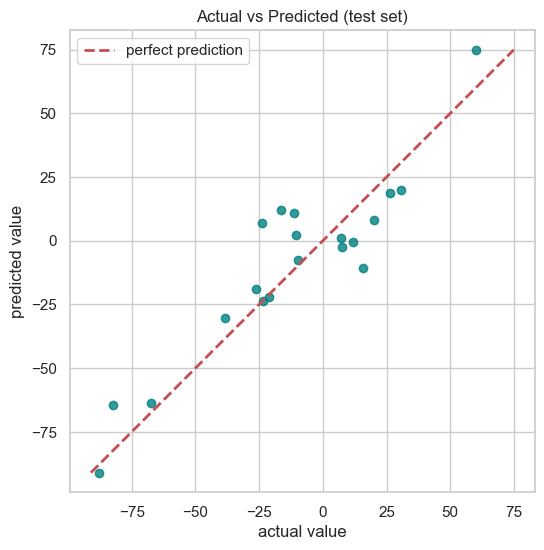

In [12]:
# Actual vs predicted: perfect predictions would land on the diagonal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, color="teal", alpha=0.8)

lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="perfect prediction")

plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("Actual vs Predicted (test set)")
plt.legend()
plt.axis("equal")
plt.show()

**Key insight:** the closer the points hug the red dashed line, the better the predictions. Points **above** the line are under-predictions; **below** are over-predictions. Tightly clustered points along the diagonal mean a high R².

### Residual plot
A **residual** is `actual − predicted` — the error left over for each point. Plotting residuals against the predictions reveals whether the model missed any structure.

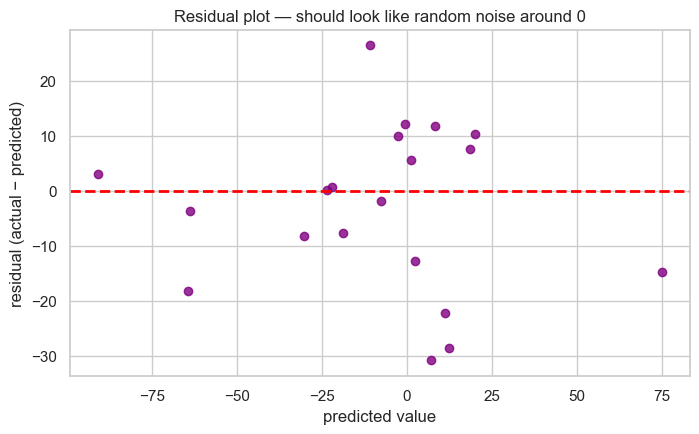

In [13]:
# Residual plot: the leftover error for each test prediction
residuals = y_test - predictions

plt.figure(figsize=(8, 4.5))
plt.scatter(predictions, residuals, color="purple", alpha=0.8)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("predicted value")
plt.ylabel("residual (actual − predicted)")
plt.title("Residual plot — should look like random noise around 0")
plt.show()

**Key insight:** a good linear model leaves residuals that look like **random noise around the red zero line**, with no pattern. If you instead saw a **curve** (a U or arch), it would mean the true relationship is non-linear and a straight line is missing structure. Here the residuals should look patternless — evidence the linear model is appropriate.

## 10. Animation — watch gradient descent learn the line

This is the highlight. We re-run gradient descent and **record the line after every step**, then play it back as an inline animation (built with `matplotlib.animation`, shown via `to_jshtml()` so it needs no extra tools). Press ▶ to watch the line rotate and slide until it fits the data.

In [14]:
from matplotlib import animation
from IPython.display import HTML

# Re-run gradient descent manually, recording the (w, b) line after each step
Xtr = np.array(X_train).ravel()
ytr = np.array(y_train)
n = len(Xtr)
w, b = 0.0, 0.0
lr = 0.05          # a slightly larger step so convergence is visible in few frames
history = []
for _ in range(40):
    y_pred = Xtr * w + b
    dw = (1 / n) * np.dot(Xtr, (y_pred - ytr))
    db = (1 / n) * np.sum(y_pred - ytr)
    w -= lr * dw
    b -= lr * db
    history.append((w, b))

line_x = np.linspace(X.min(), X.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))

def draw_step(i):
    ax.clear()
    ax.scatter(X_train, y_train, s=15, color="steelblue", label="train data")
    w_i, b_i = history[i]
    ax.plot(line_x, line_x * w_i + b_i, color="black", lw=2.5, label="current line")
    ax.set_title(f"Gradient descent — step {i + 1}/{len(history)}   (w={w_i:.1f}, b={b_i:.1f})")
    ax.set_xlabel("feature (X)")
    ax.set_ylabel("target (y)")
    ax.legend(loc="upper left")

anim = animation.FuncAnimation(fig, draw_step, frames=len(history), interval=200)
plt.close(fig)  # prevent a duplicate static figure
HTML(anim.to_jshtml())

**What to notice:** the line starts flat (`w≈0, b≈0`) and *rotates and shifts* into place as gradient descent runs. The biggest improvements happen in the first few steps, then changes get smaller as it closes in on the best fit. This is exactly the loop inside `fit` — the animation just makes each update visible.

**Learning objective:** connect the abstract "gradient descent minimizes error" to a concrete picture of a line settling onto the data.

## 11. Bonus example — learning from a real dataset (diabetes)

The synthetic data above was clean and perfectly linear. Real data is messier, so let's point the **exact same from-scratch model** at a real medical dataset.

We use scikit-learn's built-in **diabetes** dataset (no download needed): **442 patients**, each described by **10 numeric measurements** (age, sex, BMI, blood pressure, and six blood-serum values, all pre-normalized). The **target** is a continuous score of **disease progression one year later**. Predicting that number → this is again a **regression** task, now with **10 features** instead of 1.

We'll walk the full workflow again: **EDA → preprocessing → train → evaluate → predict**.

In [15]:
# Load the real diabetes dataset (bundled with scikit-learn, no download needed)
diabetes = datasets.load_diabetes()
Xd = diabetes.data                 # 442 patients x 10 features
yd = diabetes.target               # disease progression one year later
feat_names = diabetes.feature_names

# Build a DataFrame for exploration
df_d = pd.DataFrame(Xd, columns=feat_names)
df_d["target"] = yd

print("Shape (rows, cols):", df_d.shape)
print("Missing values:", df_d.isna().sum().sum())
print("Duplicate rows:", df_d.duplicated().sum())
print("Features:", feat_names)

display(df_d.head())
display(df_d.describe().round(3))

Shape (rows, cols): (442, 11)
Missing values: 0
Duplicate rows: 0
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


### Exploratory data analysis

First we inspect the table (shape, missing values, duplicates, summary stats), then we look at how each feature relates to the target using a **correlation heatmap** plus a scatter of the single strongest predictor.

*Why a heatmap here?* With 10 features, drawing a separate scatter for each would be overwhelming. A correlation heatmap compresses every pairwise relationship into one color-coded grid — the fastest way to spot which features matter and which are redundant. (Seaborn is the natural choice: a labelled, annotated heatmap in one line.)

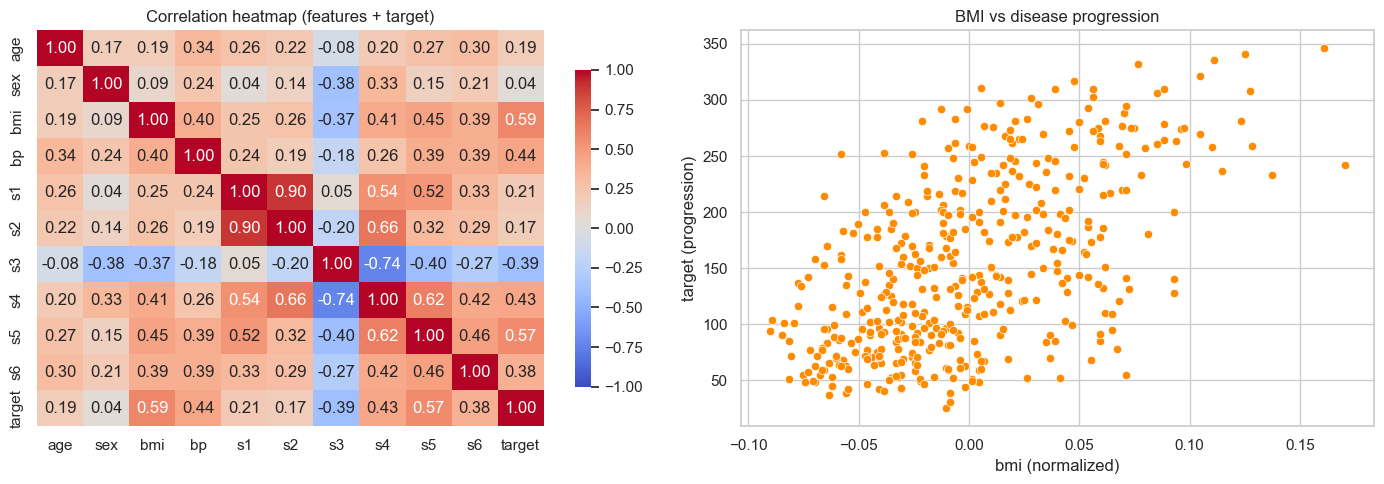

Correlation with target (strongest first):
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: target, dtype: float64


In [16]:
# EDA visuals: correlation heatmap (left) + strongest single predictor (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df_d.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation heatmap (features + target)")

sns.scatterplot(data=df_d, x="bmi", y="target", color="darkorange", ax=axes[1])
axes[1].set_title("BMI vs disease progression")
axes[1].set_xlabel("bmi (normalized)")
axes[1].set_ylabel("target (progression)")

plt.tight_layout()
plt.show()

# Rank features by how strongly they correlate with the target
print("Correlation with target (strongest first):")
print(corr["target"].drop("target").sort_values(ascending=False).round(3))

**Key insight:** **BMI** and **s5** (a blood-serum measure) have the strongest positive correlation with disease progression, while **sex** matters little on its own. Some serum features (e.g. `s1` and `s2`) are strongly correlated with *each other* — a sign of redundancy (multicollinearity) that can make individual weights harder to interpret. No single feature is a perfect predictor, so we should expect a **modest R²** — which is realistic and honest for real-world data.

### Preprocessing: scale the features, then split

Our from-scratch gradient descent is **scale-sensitive**: if features span very different ranges, the large-valued ones dominate the gradient and training crawls (or diverges). So we **standardize** every feature to mean 0 and standard deviation 1.

Order matters: we **split first**, then fit the scaler on the **training set only** and reuse it on the test set. This prevents *data leakage* — the test set must not influence anything the model learns.

In [17]:
# Split first, then scale using ONLY the training statistics (no data leakage)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.2, random_state=42
)

scaler = StandardScaler()
Xd_train = scaler.fit_transform(Xd_train)   # learn mean/std on train
Xd_test = scaler.transform(Xd_test)         # apply the same transform to test

print("Train set:", Xd_train.shape, " Test set:", Xd_test.shape)

Train set: (353, 10)  Test set: (89, 10)


With features standardized and the data split, we're ready to train — **the model code doesn't change at all**, only the data feeding it. We use a few more iterations and a slightly larger learning rate because there are now 10 features to fit.

In [18]:
# Train the SAME from-scratch model on the real, scaled data
model_d = LinearRegression(n_iterations=2000, learning_rate=0.1)
model_d.fit(Xd_train, yd_train)
pred_d = model_d.predict(Xd_test)

mse_d = mean_squared_error(yd_test, pred_d)
r2_d = r2_score(yd_test, pred_d)
print(f"Mean Squared Error: {mse_d:.2f}")
print(f"R-squared Score: {r2_d:.3f}")

Mean Squared Error: 2895.30
R-squared Score: 0.454


### Results on real data

An R² around **0.45–0.50** is typical for a linear model on this dataset — it explains roughly half the variation in progression. That may sound modest, but disease progression depends on many factors beyond these 10 measurements, so a near-perfect fit is neither expected nor realistic. This is an honest baseline on genuine data. Let's plot predictions against the truth.

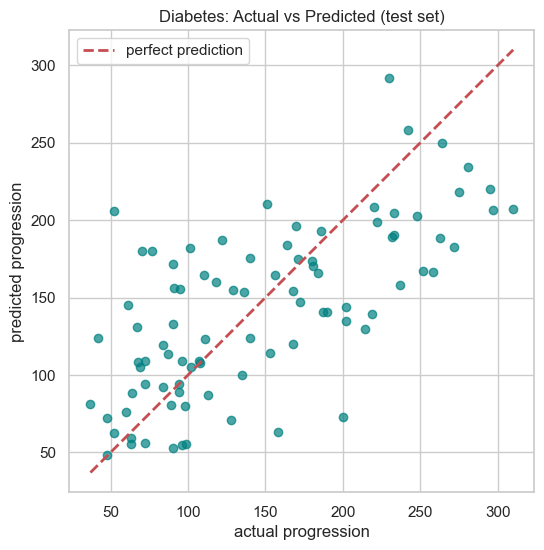

In [19]:
# Actual vs predicted on the real test set
plt.figure(figsize=(6, 6))
plt.scatter(yd_test, pred_d, color="teal", alpha=0.7)

lims = [min(yd_test.min(), pred_d.min()), max(yd_test.max(), pred_d.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="perfect prediction")

plt.xlabel("actual progression")
plt.ylabel("predicted progression")
plt.title("Diabetes: Actual vs Predicted (test set)")
plt.legend()
plt.axis("equal")
plt.show()

**Key insight:** the points scatter more loosely around the red diagonal than in the synthetic example — real data is noisier and depends on factors we didn't measure. The model still captures the overall trend (higher actual → higher predicted), just with more spread. This is exactly what an "R² ≈ 0.5" fit looks like.

In [20]:
# Predict disease progression for 5 real test patients
print("Patient |  predicted  |  actual")
for i in range(5):
    print(f"  {i:>4}   |   {pred_d[i]:7.1f}   | {yd_test[i]:6.1f}")

# Which measurements drive the prediction? (weights on standardized features)
weights_d = pd.Series(model_d.weights, index=feat_names).sort_values()
print("\nLearned feature weights (bigger magnitude = more influence):")
print(weights_d.round(2))

Patient |  predicted  |  actual
     0   |     139.7   |  219.0
     1   |     179.9   |   70.0
     2   |     135.1   |  202.0
     3   |     292.0   |  230.0
     4   |     123.3   |  111.0

Learned feature weights (bigger magnitude = more influence):
s1    -37.90
sex   -11.50
age     1.79
s6      2.40
s3      4.79
s4     12.24
bp     16.79
s2     19.51
bmi    25.73
s5     32.65
dtype: float64


### Visualising feature importance

The printed weights are much easier to compare as a chart. Because the features were standardized, the **bar lengths are directly comparable** — longer bars mean stronger influence. Green bars push predicted progression **up**, red bars pull it **down**.

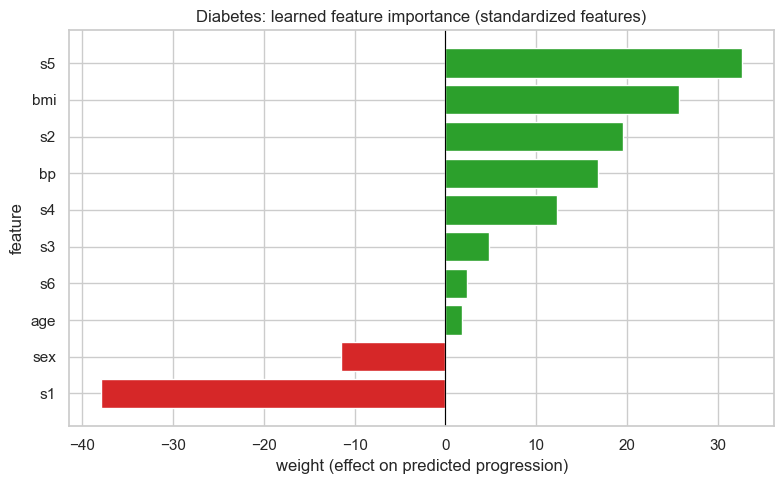

In [21]:
# Horizontal bar chart of the learned weights = feature importance
plt.figure(figsize=(8, 5))
bar_colors = ["#d62728" if w < 0 else "#2ca02c" for w in weights_d.values]
plt.barh(weights_d.index, weights_d.values, color=bar_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("weight (effect on predicted progression)")
plt.ylabel("feature")
plt.title("Diabetes: learned feature importance (standardized features)")
plt.tight_layout()
plt.show()

### Making and interpreting predictions

The table above shows the model's predicted progression next to the true value for five real patients — close in trend, not exact. The **feature weights** (learned on standardized features, so they are directly comparable) reveal *direction and strength*: a large **positive** weight (e.g. `bmi`, `s5`) means higher values push predicted progression **up**, while **negative** weights pull it **down**. This is why a linear model stays interpretable — each weight is that feature's contribution to the prediction.

## 12. Key takeaways

- Linear regression fits $\hat{y} = wx + b$ — the best straight line through the data.
- **Gradient descent** learns `w` and `b` by repeatedly stepping downhill on the error.
- **MSE** measures error (lower is better); **R²** measures explained variance (closer to 1 is better).
- Always check the **fit plot** and **residual plot**, not just the metrics — residuals should look like random noise around zero.
- The whole model is a few lines of NumPy: prediction is one dot product, learning is one gradient step repeated.
- **Real data is messier than synthetic data:** expect lower R², always **scale features** for gradient descent, and read the learned **weights** to interpret which inputs matter.

## 13. Common mistakes and troubleshooting

| Problem | Cause | Fix |
|--------|-------|-----|
| Loss becomes `nan` or explodes | Learning rate too high → gradient descent diverges | Lower `learning_rate` (e.g. 0.01) |
| Model barely learns | Learning rate too small or too few iterations | Increase `learning_rate` or `n_iterations` |
| Slow convergence on real data | Features on very different scales | **Standardize** features before training |
| Great train score, poor test score | Overfitting (less likely for a straight line) | Get more data / simplify / regularize |
| Curved residual pattern | The true relationship isn't linear | Add polynomial features or use a non-linear model |
| Test score looks too good | Scaler fit on all data before splitting (leakage) | Split first, then `fit_transform` on train, `transform` on test |

## 14. Exercises

1. **Learning rate.** Re-run training with `learning_rate=0.1` and `0.001`. What happens to the fit and to R²?
2. **Noise level.** Regenerate the synthetic data with `noise=5` and `noise=50`. How does the residual spread change?
3. **Loss curve.** Modify `fit` to store the MSE each iteration, then plot it — you should see it fall and flatten.
4. **More iterations.** Does `n_iterations=100` under-fit? Does `5000` help or just cost time?
5. **Compare.** Fit scikit-learn's `LinearRegression` on the same data and compare `weights`/`bias` and R².
6. **Real data, single feature.** On the diabetes data, train the model using **only `bmi`** and plot the fitted line. How much R² do you lose versus using all 10 features?
7. **Feature importance.** Sort the diabetes weights by absolute value — do the top features match the correlation heatmap?

## 15. Next steps and improvements

- **Compare with scikit-learn's `LinearRegression`** (which solves it exactly) to check your from-scratch result on both datasets.
- **Add feature scaling** everywhere and try multi-feature data — watch how it speeds up convergence.
- **Track the loss** each iteration and plot a **learning curve** to see training progress numerically.
- **Try regularization** (Ridge/Lasso) to handle many correlated features like the diabetes serum measures.
- **Tune the learning rate** and iterations to see the speed-vs-stability trade-off.

---
*Built from the `linear_regression.py` "ML from scratch" implementation. The model's gradient-descent logic is preserved; the tutorial structure, EDA, evaluation visuals, animation, real-data example, and explanations were added for self-study. R² was upgraded to the standard $1 - SS_{res}/SS_{tot}$ definition.*